# Binary Diffusion — Full Parameter Study (v2)

This notebook:
1. Downloads trained models from HuggingFace
2. Evaluates a **baseline** using the default parameter set
3. Runs a **full grid-search** over all parameter combinations
4. Saves **all results to a single CSV** (the source of truth for every plot)
5. Produces three types of interactive plots for report inclusion

| Parameter | Values | Scope |
|---|---|---|
| `strategy` | target, mask | always |
| `use_t_next` | False, True | always |
| `renoise_factor` | 1.0, 1.5, 2.0 | **only when `use_t_next=True`** |
| `n_timesteps` | 2, 5, 10, 20 | always |
| `schedule` | const, linear, quad | **only when `strategy=mask`** |

> **Tip:** if `study_results.csv` already exists the entire evaluation step is
> skipped — safe to re-run after any interruption or to just regenerate plots.

Ensure to have the `ipykernel` package installed in your Python environment to run this notebook.

# 1 — Configuration

In [60]:
from pathlib import Path

# ── Hugging Face ──────────────────────────────────────────────────────────────
HF_REPO = "vitaliykinakh/binary-ddpm-tabular"

# ── Datasets ──────────────────────────────────────────────────────────────────
# DATASETS = ["adult", "diabetes", "heloc", "housing", "sick", "travel"]
DATASETS = ["adult"]   # reduce for quick tests

# ── Directories ───────────────────────────────────────────────────────────────
MODELS_DIR       = "./models"
OUTPUTS_DIR      = "./outputs"
EVAL_CONFIGS_DIR = "./eval_configs"
DATA_DIR         = "./data"

# ── Results CSV ───────────────────────────────────────────────────────────────
# Single source of truth. All plots are built from this file.
# If this file exists the evaluation step is skipped entirely.
RESULTS_TABULAR_CSV = Path(OUTPUTS_DIR) / "study_results.csv"
RESULTS_IMAGE_CSV   = Path(OUTPUTS_DIR) / "study_results_images.csv"

# ── Baseline parameters ───────────────────────────────────────────────────────
# Used ONLY for the baseline run.
DEFAULT_SAMPLE_PARAMS = dict(
    n_timesteps    = 5,
    batch_size     = 2048,
    guidance_scale = 5.0,
    use_ema        = True,
    strategy       = "target",
    schedule       = "const",   # not applied for strategy=target, kept as default
    renoise_factor = 1.0,
    use_t_next     = True,
    dropna         = True,
    threshold      = 0.5,
)

# ── Parameter grid ────────────────────────────────────────────────────────────
# Semantic constraints are enforced at combo-generation time (see Cell 4):
#   1. `schedule`       varies only when strategy   = "mask"
#   2. `renoise_factor` varies only when use_t_next = True
PARAM_GRID = dict(
    strategy       = ["target", "mask"],
    use_t_next     = [False, True],
    renoise_factor = [1.0, 1.5, 2.0],   # explored only when use_t_next=True
    n_timesteps    = [2, 5, 10, 20],
    schedule       = ["const", "linear", "quad"],  # explored only when strategy="mask"
)
PARAM_KEYS = list(PARAM_GRID.keys())

# Parameters kept constant during the grid search
FIXED_PARAMS = dict(
    threshold      = 0.5,
    batch_size     = 2048,
    guidance_scale = 5.0,
    use_ema        = True,
    dropna         = True,
)

# ── Study settings ────────────────────────────────────────────────────────────
N_RUNS_PER_STEP = 5   # independent runs per config (used to estimate std)

# 2 — Imports

In [61]:
import yaml
from typing    import Any, Dict, List
from itertools import combinations

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from huggingface_hub import hf_hub_download
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

from sample   import sample
from evaluate import evaluate

Path(OUTPUTS_DIR).mkdir(parents=True, exist_ok=True)


# 3 — Download models from HuggingFace

In [62]:
def download_models(datasets, repo, models_dir):
    """Download model-final.pt and transformation.joblib for each dataset."""
    paths = {}
    for ds in datasets:
        dst = Path(models_dir) / ds
        dst.mkdir(parents=True, exist_ok=True)
        model_path     = dst / "model-final.pt"
        transform_path = dst / "transformation.joblib"
        if not model_path.exists():
            print(f"[{ds}] Downloading model …")
            hf_hub_download(repo_id=repo,
                            filename=f"{ds}/model-final.pt",
                            local_dir=models_dir)
        if not transform_path.exists():
            print(f"[{ds}] Downloading transformation …")
            hf_hub_download(repo_id=repo,
                            filename=f"{ds}/transformation.joblib",
                            local_dir=models_dir)
        paths[ds] = dict(ckpt=str(model_path), ckpt_transformation=str(transform_path))
        print(f"[{ds}] ✓ ready")
    return paths

model_paths = download_models(DATASETS, HF_REPO, MODELS_DIR)


[adult] ✓ ready


# 4 — Helper functions

In [63]:
# ── Dataset helpers ───────────────────────────────────────────────────────────

def get_n_samples(dataset_name):
    """Count training rows (excl. header)."""
    train_csv = Path(DATA_DIR) / f"{dataset_name}_train.csv"
    return sum(1 for _ in open(train_csv)) - 1

def get_target_column(dataset_name):
    """Read target_column from the eval YAML config."""
    cfg_path = Path(EVAL_CONFIGS_DIR) / f"{dataset_name}.yml"
    cfg = yaml.safe_load(open(cfg_path))
    return cfg["data"]["target_column"]

def build_eval_cfg(dataset_name, synthetic_paths):
    """Load the eval config and patch path_synthetic_trains + path_test."""
    cfg_path = Path(EVAL_CONFIGS_DIR) / f"{dataset_name}.yml"
    cfg = yaml.safe_load(open(cfg_path))
    cfg["path_synthetic_trains"] = [str(p) for p in synthetic_paths]
    cfg["path_test"]             = str(Path(DATA_DIR) / f"{dataset_name}_test.csv")
    return cfg


# ── Combo generation ──────────────────────────────────────────────────────────

def build_param_combos(param_grid: dict) -> List[Dict[str, Any]]:
    """
    Build all parameter combos, enforcing two semantic constraints:

    1. ``schedule`` only varies when ``strategy == "mask"``.
       For ``strategy == "target"`` the schedule parameter is not applied by
       the sampler, so we fix it to the first grid value ("const") and avoid
       duplicating runs.

    2. ``renoise_factor`` only varies when ``use_t_next == True``.
       When use_t_next is False the re-noising step is never executed, so
       renoise_factor is fixed at 1.0.
    """
    combos = []
    for strategy in param_grid["strategy"]:
        schedules = (param_grid["schedule"] if strategy == "mask"
                     else [param_grid["schedule"][0]])
        for use_t_next in param_grid["use_t_next"]:
            renoise_factors = (param_grid["renoise_factor"] if use_t_next
                               else [1.0])
            for n_timesteps in param_grid["n_timesteps"]:
                for schedule in schedules:
                    for rn in renoise_factors:
                        combos.append(dict(
                            strategy       = strategy,
                            use_t_next     = use_t_next,
                            renoise_factor = rn,
                            n_timesteps    = n_timesteps,
                            schedule       = schedule,
                        ))
    # Deduplicate while preserving order
    seen, unique = set(), []
    for c in combos:
        k = tuple(sorted(c.items()))
        if k not in seen:
            seen.add(k)
            unique.append(c)
    return unique

ALL_COMBOS = build_param_combos(PARAM_GRID)
print(f"Total combinations   : {len(ALL_COMBOS)}")
print(f"Runs per combination : {N_RUNS_PER_STEP}")
print(f"Datasets             : {DATASETS}")
print(f"Total sampling calls : {len(ALL_COMBOS) * N_RUNS_PER_STEP * len(DATASETS)}")


# ── Combo → filesystem-safe key string ───────────────────────────────────────

_ABBR = dict(
    strategy       = "st",
    use_t_next     = "tnxt",
    renoise_factor = "rn",
    n_timesteps    = "T",
    schedule       = "sc",
)

def combo_key(combo: Dict[str, Any]) -> str:
    """
    Compact, filesystem-safe string key for a parameter combo.
    Example: 'st=mask__tnxt=T__rn=1__T=5__sc=const'
    """
    parts = []
    for k in PARAM_KEYS:
        v = combo[k]
        if isinstance(v, bool):
            v = "T" if v else "F"
        elif isinstance(v, float) and v == int(v):
            v = int(v)
        parts.append(f"{_ABBR[k]}={v}")
    return "__".join(parts)

# Sanity check
print("Key [0] :", combo_key(ALL_COMBOS[0]))
print("Key [-1]:", combo_key(ALL_COMBOS[-1]))


Total combinations   : 64
Runs per combination : 5
Datasets             : ['adult']
Total sampling calls : 320
Key [0] : st=target__tnxt=F__rn=1__T=2__sc=const
Key [-1]: st=mask__tnxt=T__rn=2__T=20__sc=quad


# 5 — Baseline

Generate synthetic samples with the **default** parameter set.
Gives a reference score every grid-search config is compared against.
Files that already exist are skipped — safe to re-run.


In [64]:
baseline_csv: Dict[str, List[Path]] = {}

for ds in DATASETS:
    n_samples = get_n_samples(ds)
    out_dir   = Path(OUTPUTS_DIR) / ds / "baseline"
    out_dir.mkdir(parents=True, exist_ok=True)
    csvs = []

    for run in range(N_RUNS_PER_STEP):
        out_path = out_dir / f"samples_{run}.csv"
        if out_path.exists():
            print(f"[{ds}] baseline run {run} already exists — skipping")
        else:
            print(f"[{ds}] generating baseline run {run} …")
            sample(
                ckpt                = model_paths[ds]["ckpt"],
                ckpt_transformation = model_paths[ds]["ckpt_transformation"],
                out                 = str(out_path),
                n_samples           = n_samples,
                target_column_name  = get_target_column(ds),
                **DEFAULT_SAMPLE_PARAMS,
            )
        csvs.append(out_path)

    baseline_csv[ds] = csvs
    print(f"[{ds}] ✓ {len(csvs)} baseline files ready\n")


[adult] baseline run 0 already exists — skipping
[adult] baseline run 1 already exists — skipping
[adult] baseline run 2 already exists — skipping
[adult] baseline run 3 already exists — skipping
[adult] baseline run 4 already exists — skipping
[adult] ✓ 5 baseline files ready



# 6 — Full grid-search

## 6.1 — Generate samples

Iterates over every **(dataset × combo × run)** triple.
Files that already exist are skipped — safe to resume after any interruption.


In [65]:
if RESULTS_TABULAR_CSV.exists():
    print(f"✅  Found cached results: {RESULTS_TABULAR_CSV}")
    print("   Skipping all evaluation — plots will be built from the CSV.\n")
else:

    study_csv: Dict[str, Dict[str, List[Path]]] = {ds: {} for ds in DATASETS}
    new_runs = skipped_runs = 0

    for ds in DATASETS:
        n_samples = get_n_samples(ds)

        for idx, combo in enumerate(ALL_COMBOS):
            key     = combo_key(combo)
            out_dir = Path(OUTPUTS_DIR) / ds / key
            out_dir.mkdir(parents=True, exist_ok=True)

            csvs: List[Path] = []
            for run in range(N_RUNS_PER_STEP):
                out_path = out_dir / f"samples_{run}.csv"
                if out_path.exists():
                    skipped_runs += 1
                else:
                    print(f"[{ds} | {idx+1}/{len(ALL_COMBOS)} | run {run}] {key}")
                    sample(
                        ckpt                = model_paths[ds]["ckpt"],
                        ckpt_transformation = model_paths[ds]["ckpt_transformation"],
                        out                 = str(out_path),
                        n_samples           = n_samples,
                        target_column_name  = get_target_column(ds),
                        **combo,
                        **FIXED_PARAMS,
                    )
                    new_runs += 1
                csvs.append(out_path)

            study_csv[ds][key] = csvs

    print(f"\n✅ Generation done — {new_runs} new files, {skipped_runs} skipped.")


✅  Found cached results: outputs\study_results.csv
   Skipping all evaluation — plots will be built from the CSV.



## 6.2 — Evaluate all configurations & save to CSV

If `study_results.csv` already exists this entire cell is skipped.
To force a full re-evaluation, delete the CSV file and re-run.

The CSV contains **one row per (dataset × downstream model × parameter combo)**
and includes:
- all parameter columns
- `mean` / `std` scores
- `baseline_mean` — the baseline score for the same dataset × model
- `delta_vs_baseline` — `mean − baseline_mean` (positive = improvement)
- `is_baseline` flag


In [66]:
if RESULTS_TABULAR_CSV.exists():
    print(f"✅  Found cached results: {RESULTS_TABULAR_CSV}")
    print("   Skipping all evaluation — plots will be built from the CSV.\n")

else:
    print(f"No cached results found at {RESULTS_TABULAR_CSV}.")
    print("Running evaluation … (this may take ~1 hour)\n")

    # ── Evaluate baseline ──────────────────────────────────────────────────────
    _baseline_results: Dict[str, Any] = {}
    for ds in DATASETS:
        cfg = build_eval_cfg(ds, baseline_csv[ds])
        res = evaluate(cfg)
        _baseline_results[ds] = res
        print(f"[{ds}] baseline metric = {res['metric']}")
        for model_name, scores in res["models"].items():
            print(f"  {model_name}: {scores['mean']:.4f} ± {scores['std']:.4f}")
        print()

    # ── Evaluate all grid-search combos ───────────────────────────────────────
    _study_results: Dict[str, Dict[str, Any]] = {ds: {} for ds in DATASETS}
    for ds in DATASETS:
        for idx, combo in enumerate(ALL_COMBOS):
            key = combo_key(combo)
            print(f"[{ds} | {idx+1:>3}/{len(ALL_COMBOS)}] {key}")
            cfg = build_eval_cfg(ds, study_csv[ds][key])
            _study_results[ds][key] = evaluate(cfg)

    # ── Flatten to tidy records ────────────────────────────────────────────────
    records: List[Dict[str, Any]] = []

    for ds in DATASETS:
        _b_res    = _baseline_results[ds]
        _b_metric = _b_res["metric"]
        # Per-model baseline mean used to compute deltas
        _b_scores = {m: v["mean"] for m, v in _b_res["models"].items()}

        # Baseline rows (delta = 0 by definition)
        for model_name, model_res in _b_res["models"].items():
            records.append(dict(
                dataset           = ds,
                model             = model_name,
                metric            = _b_metric,
                key               = "BASELINE",
                is_baseline       = True,
                **{k: DEFAULT_SAMPLE_PARAMS.get(k) for k in PARAM_KEYS},
                mean              = model_res["mean"],
                std               = model_res["std"],
                baseline_mean     = model_res["mean"],
                delta_vs_baseline = 0.0,
            ))

        # Grid-search rows
        for combo in ALL_COMBOS:
            key    = combo_key(combo)
            result = _study_results[ds][key]
            metric = result["metric"]
            for model_name, model_res in result["models"].items():
                b_mean = _b_scores.get(model_name, float("nan"))
                records.append(dict(
                    dataset           = ds,
                    model             = model_name,
                    metric            = metric,
                    key               = key,
                    is_baseline       = False,
                    **combo,
                    mean              = model_res["mean"],
                    std               = model_res["std"],
                    baseline_mean     = b_mean,
                    delta_vs_baseline = model_res["mean"] - b_mean,
                ))

    _records_df = pd.DataFrame(records)
    for col in ["use_t_next", "is_baseline"]:
        if col in _records_df.columns:
            _records_df[col] = _records_df[col].astype(bool)

    _records_df.to_csv(RESULTS_TABULAR_CSV, index=False)
    print(f"\n✅  Saved {len(_records_df)} rows → {RESULTS_TABULAR_CSV}")
    print("    Re-run any cell below without re-evaluating by keeping this file.")


✅  Found cached results: outputs\study_results.csv
   Skipping all evaluation — plots will be built from the CSV.



## 6.3 — Load results DataFrame
*(Always execute this cell — it is the single entry-point for all plots and tables)*


In [67]:
results_df = pd.read_csv(RESULTS_TABULAR_CSV)

# Restore correct dtypes
for col in ["use_t_next", "is_baseline"]:
    if col in results_df.columns:
        results_df[col] = results_df[col].astype(bool)

# Convenience sub-frames
baseline_df = results_df[results_df["is_baseline"]].copy()
study_df    = results_df[~results_df["is_baseline"]].copy()

# Per-dataset baseline mean (averaged across downstream models)
baseline_mean_per_ds = (
    baseline_df.groupby("dataset")["mean"].mean().to_dict()
)

print(f"results_df  : {results_df.shape[0]} rows × {results_df.shape[1]} cols")
print(f"  — baseline : {baseline_df.shape[0]} rows")
print(f"  — study    : {study_df.shape[0]} rows")
print(f"Datasets    : {sorted(results_df['dataset'].unique())}")
print(f"Models      : {sorted(results_df['model'].unique())}")
print(f"Metric      : {results_df['metric'].iloc[0]}")
print(f"\nBaseline mean per dataset:")
for ds, v in baseline_mean_per_ds.items():
    print(f"  {ds}: {v:.4f}")

results_df.head()


results_df  : 195 rows × 14 cols
  — baseline : 3 rows
  — study    : 192 rows
Datasets    : ['adult']
Models      : ['DT', 'LR', 'RF']
Metric      : accuracy

Baseline mean per dataset:
  adult: 0.8268


,dataset,model,metric,key,is_baseline,strategy,use_t_next,renoise_factor,n_timesteps,schedule,mean,std,baseline_mean,delta_vs_baseline
0,adult,LR,accuracy,BASELINE,True,target,True,1.0000,5,const,0.8377,0.0037,0.8377,0.0000
1,adult,DT,accuracy,BASELINE,True,target,True,1.0000,5,const,0.8206,0.0086,0.8206,0.0000
2,adult,RF,accuracy,BASELINE,True,target,True,1.0000,5,const,0.8221,0.0032,0.8221,0.0000
3,adult,LR,accuracy,st=target__tnxt=F__rn=1__T=2__sc=const,False,target,False,1.0000,2,const,0.8249,0.0025,0.8377,-0.0128
4,adult,DT,accuracy,st=target__tnxt=F__rn=1__T=2__sc=const,False,target,False,1.0000,2,const,0.8073,0.0048,0.8206,-0.0133


# 7 — Analysis & Visualisation

## 7.1 — Utilities for plotting results from the CSV file.

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

# use_kid sub-cell definitions: (column, low_is_better, short_label)
# Layout per cell:  FID  | FID-C
#                    IS  |  KID
_KID = [
    ("fid",             True,  "FID"),
    ("fid_clip",        True,  "FID-C"),
    ("inception_score", False, "IS"),
    ("kid",             True,  "KID"),
]
_KID_OFFSETS = [(-0.5, -0.5), (0.0, -0.5), (-0.5, 0.0), (0.0, 0.0)]


def _text_color(rgba):
    lum = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return "#111" if lum > 0.45 else "#eee"


def plot_heatmaps(
    df:             pd.DataFrame,
    x_col:          str,
    y_col:          str,
    value_col:      str   = None,   # required when use_kid=False
    fixed_filters:  dict  = None,
    subplot_cols:   list  = None,
    ncols:          int   = 3,
    cell_size:      tuple = (5, 4),
    suptitle:       str   = "",
    low_is_better:  bool  = False,
    aggfunc:        str   = "mean",
    fmt:            str   = ".4f",
    annot_fontsize: int   = 10,
    use_kid:        bool  = False,
    std_col:        str   = None,   # ← NEW: pre-computed std column (non-KID mode).
                                    #        KID mode auto-detects "{metric}_std" columns
                                    #        (e.g. "fid_std", "kid_std", …).
) -> plt.Figure:
    """
    Plot a grid of annotated heatmaps from a tidy DataFrame.

    value_col is optional when use_kid=True (metrics are fid, fid_clip,
    inception_score, kid). Each cell shows four colour-coded sub-cells:
        FID  | FID-C      lower = greener
         IS  |  KID       IS: higher = greener; others: lower = greener

    Colour scale is a plain min→max linear ramp per metric,
    computed independently per subplot (so each subplot's own min/max
    always maps to the full red→green range).

    std_col (non-KID): name of a column holding pre-computed std values;
        shown as "mean\\n±std" inside each cell.
    KID mode: std is shown automatically whenever a column named
        "{metric}_std" exists in df (e.g. "fid_std", "inception_score_std").
    """
    if not use_kid and value_col is None:
        raise ValueError("value_col is required when use_kid=False")

    # ── 1. Fixed filters ────────────────────────────────────────────────────
    data = df.copy()
    for col, val in (fixed_filters or {}).items():
        data = data[data[col] == val]

    # ── 2. Subplot groups ────────────────────────────────────────────────────
    subplot_cols = subplot_cols or []
    groups = (
        [(k if isinstance(k, tuple) else (k,), g)
         for k, g in data.groupby(subplot_cols)]
        if subplot_cols else [((), data)]
    )
    n      = len(groups)
    ncols_ = min(ncols, n)
    nrows_ = int(np.ceil(n / ncols_))

    def make_pivot(grp, col):
        return grp.pivot_table(index=y_col, columns=x_col,
                               values=col, aggfunc=aggfunc)

    # ── 3. Precompute pivots & colormaps (norms are per-subplot, see § 4) ────
    std_pivots   = None  # ← NEW: populated below for non-KID mode
    kid_std_info = {}    # ← NEW: populated below for KID mode

    if use_kid:
        kid_info = {}
        for col, lib, _ in _KID:
            pivs = [make_pivot(g, col) for _, g in groups]
            kid_info[col] = (
                pivs,
                plt.get_cmap("RdYlGn_r" if lib else "RdYlGn"),
            )
        ref_pivots = kid_info["fid"][0]

        # ← NEW: auto-detect "{metric}_std" columns ──────────────────────────
        for col, _, _ in _KID:
            std_c = f"{col}_std"
            if std_c in data.columns:
                kid_std_info[col] = [make_pivot(g, std_c) for _, g in groups]
        # ─────────────────────────────────────────────────────────────────────
    else:
        ref_pivots = [make_pivot(g, value_col) for _, g in groups]
        cmap_s = plt.get_cmap("RdYlGn_r" if low_is_better else "RdYlGn")

        # ← NEW: build std pivots when std_col is provided ────────────────────
        if std_col is not None and std_col in data.columns:
            std_pivots = [make_pivot(g, std_col) for _, g in groups]
        # ─────────────────────────────────────────────────────────────────────

    # ── 4. Draw ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        nrows_, ncols_,
        figsize   = (ncols_ * cell_size[0], nrows_ * cell_size[1] + 0.8),
        squeeze   = False,
        facecolor = "white",
    )

    for idx, ((key, _), ref_piv) in enumerate(zip(groups, ref_pivots)):
        ax     = axes[idx // ncols_][idx % ncols_]
        ny, nx = ref_piv.shape

        if use_kid:
            # Per-subplot, per-metric norms (each subplot's own min/max)
            subplot_norms = {}
            for col, _, _ in _KID:
                pivs, _ = kid_info[col]
                local_vals = pivs[idx].values.ravel()
                local_vals = local_vals[np.isfinite(local_vals)]
                subplot_norms[col] = mcolors.Normalize(
                    local_vals.min(), local_vals.max()
                )

            ax.set_xlim(-0.5, nx - 0.5)
            ax.set_ylim(ny - 0.5, -0.5)          # invert y like imshow

            for yi in range(ny):
                for xi in range(nx):
                    for (col, _, label), (dx, dy) in zip(_KID, _KID_OFFSETS):
                        pivs, cmap_ = kid_info[col]
                        norm_ = subplot_norms[col]
                        v = float(pivs[idx].values[yi, xi])
                        if not np.isfinite(v):
                            continue
                        rgba = cmap_(norm_(v))
                        tc   = _text_color(rgba)
                        rx, ry = xi + dx, yi + dy
                        ax.add_patch(Rectangle(
                            (rx, ry), 0.5, 0.5,
                            facecolor=rgba, edgecolor="white",
                            linewidth=0.3, zorder=1,
                        ))
                        cx, cy_c = rx + 0.25, ry + 0.25

                        # ← NEW: build value string, shift positions when std present
                        val_str  = format(v, fmt)
                        label_dy = -0.10                   # default label offset
                        val_dy   = +0.10                   # default value offset
                        val_fs   = annot_fontsize * 0.72   # default value font size
                        if col in kid_std_info:
                            sv = float(kid_std_info[col][idx].values[yi, xi])
                            if np.isfinite(sv):
                                val_str  = f"{val_str}\n±{format(sv, fmt)}"
                                label_dy = -0.14           # push label up
                                val_dy   = +0.06           # center the 2-liner
                                val_fs   = annot_fontsize * 0.60
                        # ─────────────────────────────────────────────────────

                        ax.text(cx, cy_c + label_dy, label,
                                ha="center", va="center", color=tc,
                                fontsize=annot_fontsize * 0.55,
                                fontweight="bold", zorder=3)
                        ax.text(cx, cy_c + val_dy, val_str,
                                ha="center", va="center", color=tc,
                                fontsize=val_fs, zorder=3,
                                linespacing=1.15)          # ← NEW: tighten 2-liner
        else:
            mat = ref_piv.values.astype(float)
            # Per-subplot norm (this subplot's own min/max)
            flat_local = mat.ravel()
            flat_local = flat_local[np.isfinite(flat_local)]
            norm_s = mcolors.Normalize(flat_local.min(), flat_local.max())

            ax.imshow(mat, cmap=cmap_s, norm=norm_s,
                      aspect="auto", interpolation="nearest")
            for yi in range(ny):
                for xi in range(nx):
                    v = mat[yi, xi]
                    if not np.isfinite(v):
                        continue
                    rgba = cmap_s(norm_s(v))

                    # ← NEW: append "±std" line when std_pivots available
                    txt    = format(v, fmt)
                    ann_fs = annot_fontsize
                    if std_pivots is not None:
                        sv = std_pivots[idx].values[yi, xi]
                        if np.isfinite(sv):
                            txt    = f"{txt}\n±{format(sv, fmt)}"
                            ann_fs = annot_fontsize * 0.82
                    # ─────────────────────────────────────────────────────────

                    ax.text(xi, yi, txt,
                            ha="center", va="center",
                            fontsize=ann_fs, fontweight="bold",
                            color=_text_color(rgba), zorder=3,
                            linespacing=1.2)               # ← NEW: tighten 2-liner

        for x in np.arange(-0.5, nx, 1):
            ax.axvline(x, color="white", linewidth=0.8, zorder=2)
        for y in np.arange(-0.5, ny, 1):
            ax.axhline(y, color="white", linewidth=0.8, zorder=2)

        ax.set_xticks(range(nx))
        ax.set_yticks(range(ny))
        ax.set_xticklabels([str(v) for v in ref_piv.columns])
        ax.set_yticklabels([str(v) for v in ref_piv.index])
        ax.set_xlabel(x_col, fontsize=10, labelpad=6)
        ax.set_ylabel(y_col, fontsize=10, labelpad=6)

        title = ("  ·  ".join(f"{c}={v}" for c, v in zip(subplot_cols, key))
                 if subplot_cols else (value_col or "metrics"))
        ax.set_title(title, fontsize=10, fontweight="semibold", pad=8)

    for idx in range(n, nrows_ * ncols_):
        axes[idx // ncols_][idx % ncols_].set_visible(False)

    fig.suptitle(suptitle, fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig

## 7.2 — n_timesteps × schedule line plots


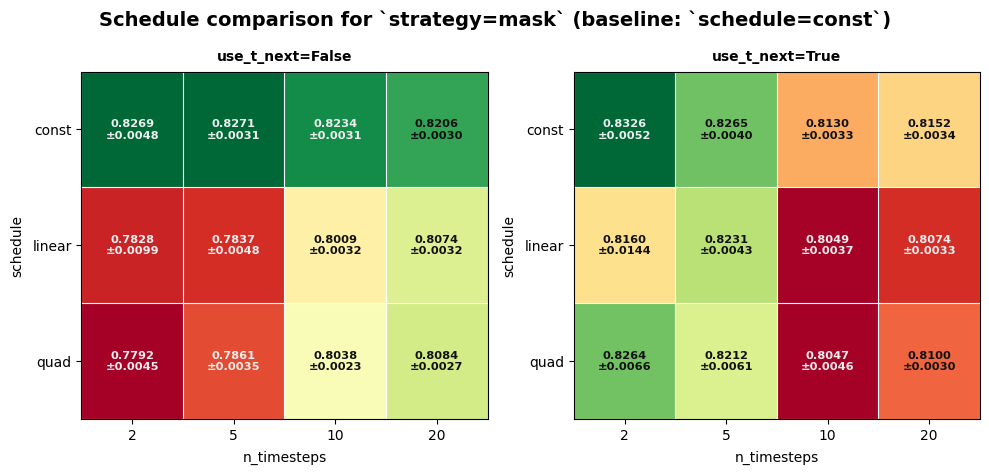

In [69]:
df = pd.read_csv(RESULTS_TABULAR_CSV)

fig1 = plot_heatmaps(
    df,
    value_col     = "mean",
    x_col         = "n_timesteps",
    y_col         = "schedule",
    fixed_filters = {"strategy": "mask", "renoise_factor": 1.0},
    subplot_cols  = ["use_t_next"],
    # ncols         = 2,
    suptitle      = "Schedule comparison for `strategy=mask` (baseline: `schedule=const`)",
    cell_size      = (5, 4),
    std_col        = "std",
)
plt.show()


## 7.3 — Fixing noise addition during sampling


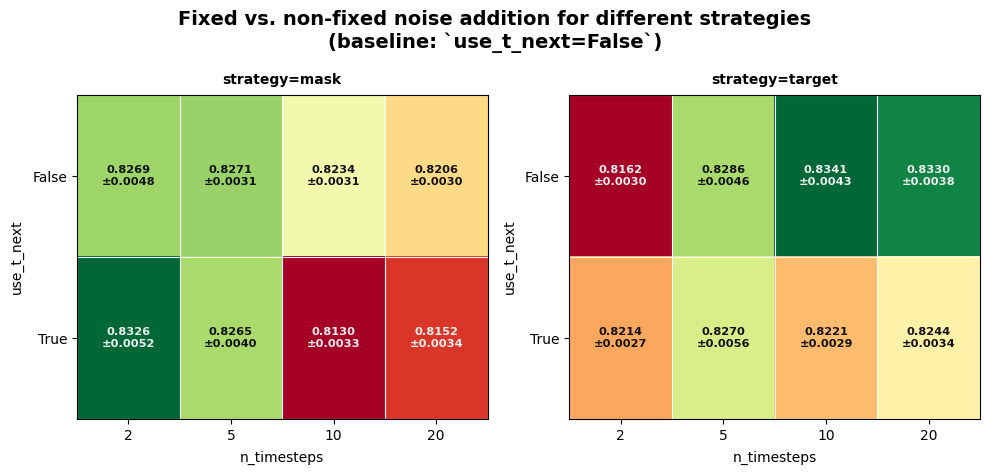

In [70]:
fig2 = plot_heatmaps(
    df,
    value_col     = "mean",
    x_col         = "n_timesteps",
    y_col         = "use_t_next",
    fixed_filters = {"renoise_factor": 1.0, "schedule": "const"},
    subplot_cols  = ["strategy"],
    ncols         = 2,
    suptitle      = "Fixed vs. non-fixed noise addition for different strategies\n(baseline: `use_t_next=False`)",
    cell_size      = (5, 4),
    std_col        = "std",
)
plt.show()

## 7.4 - Increasing the noise in the sampling process

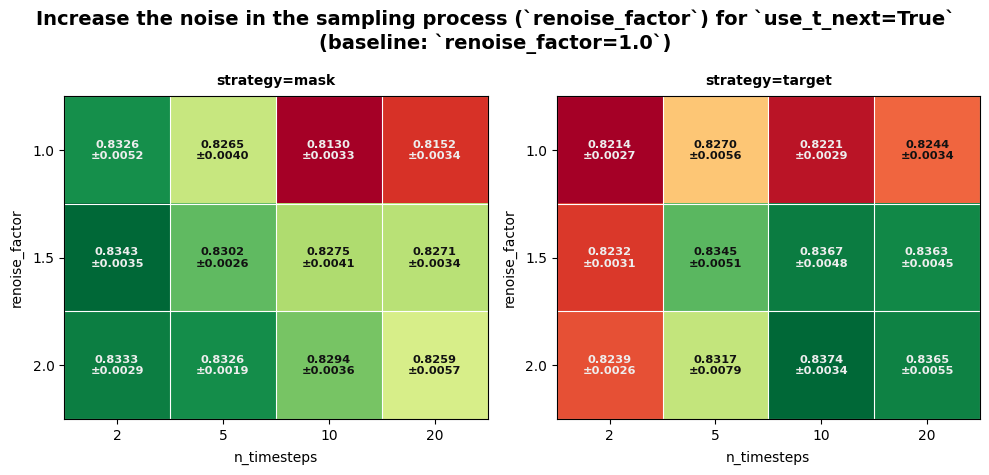

In [71]:
fig2 = plot_heatmaps(
    df,
    value_col     = "mean",
    x_col         = "n_timesteps",
    y_col         = "renoise_factor",
    fixed_filters = {"use_t_next": True, "schedule": "const"},
    subplot_cols  = ["strategy"],
    ncols         = 2,
    suptitle      = "Increase the noise in the sampling process (`renoise_factor`) for `use_t_next=True`\n(baseline: `renoise_factor=1.0`)",
    cell_size      = (5, 4),
    std_col        = "std",
)
plt.show()

# 8 — Ranked summary table

- 🟩 Green / 🟥 Red gradient on `mean_all_models` (study rows only)
- 🔵 Blue row = the **baseline** configuration
- 🟢 Green / 🔴 Red text on `delta_vs_baseline`


In [72]:
def build_study_table(df, param_keys):
    """
    Wide-format summary: one row per (dataset, combo).
    Columns: param_keys + one per downstream model + mean_all_models + std_all_models.
    Sorted best-first by mean_all_models.
    """
    model_names = sorted(df["model"].unique())
    pivot = (
        df.pivot_table(
            index=["dataset", "key", *param_keys],
            columns="model",
            values="mean",
            aggfunc="mean",
        )
        .reset_index()
    )
    pivot.columns.name = None
    pivot["mean_all_models"] = pivot[model_names].mean(axis=1)
    pivot["std_all_models"]  = pivot[model_names].std(axis=1)
    pivot = pivot.sort_values("mean_all_models", ascending=False).reset_index(drop=True)
    pivot.insert(0, "rank", range(1, len(pivot) + 1))
    return pivot, model_names


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

for ds in DATASETS:
    df_ds      = study_df[study_df["dataset"] == ds]
    df_base_ds = baseline_df[baseline_df["dataset"] == ds]
    metric_name = df_ds["metric"].iloc[0]
    b_mean      = baseline_mean_per_ds.get(ds, float("nan"))

    # ── Build ranked table ────────────────────────────────────────────────────
    table, model_names = build_study_table(df_ds, PARAM_KEYS)
    table["delta_vs_baseline"] = table["mean_all_models"] - b_mean

    # ── Baseline row ──────────────────────────────────────────────────────────
    b_means = df_base_ds.groupby("model")["mean"].mean().to_dict()
    baseline_row = pd.DataFrame([{
        "rank"             : "BASE",
        "dataset"          : ds,
        "key"              : "BASELINE",
        **{k: DEFAULT_SAMPLE_PARAMS.get(k, "—") for k in PARAM_KEYS},
        **{m: round(b_means.get(m, float("nan")), 4) for m in model_names},
        "mean_all_models"  : round(b_mean, 4),
        "std_all_models"   : round(
            pd.Series(list(b_means.values())).std(), 4),
        "delta_vs_baseline": 0.0,
    }])

    # ── Assemble display table ────────────────────────────────────────────────
    display_cols = (
        ["rank", "dataset"]
        + PARAM_KEYS
        + model_names
        + ["mean_all_models", "std_all_models", "delta_vs_baseline"]
    )
    float_cols = model_names + ["mean_all_models", "std_all_models", "delta_vs_baseline"]

    study_display    = table[[c for c in display_cols if c in table.columns]].copy()
    baseline_display = baseline_row[[c for c in display_cols
                                     if c in baseline_row.columns]].copy()
    full_display     = pd.concat([baseline_display, study_display], ignore_index=True)

    # ── Styler ────────────────────────────────────────────────────────────────
    study_means = study_display["mean_all_models"].dropna()
    vmin_style  = study_means.quantile(0.1)
    vmax_style  = study_means.quantile(0.9)

    def highlight_baseline(row):
        if row["rank"] == "BASE":
            return ["background-color: #cce5ff; font-weight: bold"] * len(row)
        return [""] * len(row)

    def color_delta(val):
        if pd.isna(val) or val == 0:
            return ""
        return "color: green; font-weight: bold" if val > 0 else "color: #cc0000"

    styled = (
        full_display.style
        .apply(highlight_baseline, axis=1)
        .background_gradient(
            subset=["mean_all_models"],
            cmap="RdYlGn", vmin=vmin_style, vmax=vmax_style,
        )
        .background_gradient(subset=model_names, cmap="Blues", axis=0)
        .applymap(color_delta, subset=["delta_vs_baseline"])
        .format({c: "{:.4f}" for c in float_cols}, na_rep="—")
        .set_caption(
            f"{len(study_display)} configurations — Dataset: {ds}  |  "
            f"Metric: {metric_name}  |  "
            f"Sorted best → worst  |  "
            f"Baseline (blue row): {b_mean:.4f}"
        )
        .set_table_styles([{
            "selector": "caption",
            "props": ("font-size:13px; font-weight:bold; "
                      "text-align:left; margin-bottom:6px; caption-side:top;"),
        }])
    )
    display(styled)
    print()


C:\Users\Sinbad\AppData\Local\Temp\ipykernel_30740\3344044193.py:89: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_delta, subset=["delta_vs_baseline"])


,rank,dataset,strategy,use_t_next,renoise_factor,n_timesteps,schedule,DT,LR,RF,mean_all_models,std_all_models,delta_vs_baseline
0,BASE,adult,target,True,1.000000,5,const,0.8206,0.8377,0.8221,0.8268,0.0094,0.0000
1,1,adult,target,True,2.000000,10,const,0.8333,0.8464,0.8326,0.8374,0.0078,0.0106
2,2,adult,target,True,1.500000,10,const,0.8337,0.8475,0.8290,0.8367,0.0096,0.0099
3,3,adult,target,True,2.000000,20,const,0.8307,0.8463,0.8325,0.8365,0.0085,0.0097
4,4,adult,target,True,1.500000,20,const,0.8349,0.8446,0.8295,0.8363,0.0077,0.0095
5,5,adult,target,True,1.500000,5,const,0.8309,0.8447,0.8279,0.8345,0.0090,0.0076
6,6,adult,mask,True,1.500000,2,const,0.8283,0.8403,0.8345,0.8343,0.0060,0.0075
7,7,adult,target,False,1.000000,10,const,0.8332,0.8409,0.8282,0.8341,0.0064,0.0073
8,8,adult,mask,True,2.000000,2,const,0.8350,0.8353,0.8298,0.8333,0.0031,0.0065
9,9,adult,target,False,1.000000,20,const,0.8318,0.8397,0.8275,0.8330,0.0062,0.0062


## 8.1 — Top-5 / Bottom-5 configurations vs baseline

In [73]:
for ds in DATASETS:
    df_ds       = study_df[study_df["dataset"] == ds]
    metric_name = df_ds["metric"].iloc[0]
    b_mean      = baseline_mean_per_ds.get(ds, float("nan"))

    agg = (
        df_ds.groupby(["key", *PARAM_KEYS])["mean"]
        .mean()
        .reset_index()
        .rename(columns={"mean": "mean_all_models"})
        .sort_values("mean_all_models", ascending=False)
        .reset_index(drop=True)
    )

    sep = "=" * 80
    print(f"{sep}")
    print(f"Dataset : {ds}  |  Metric : {metric_name}")
    print(f"{sep}")
    print(f"  Baseline mean_all_models = {b_mean:.4f}")
    print()

    for label, subset in [("Top-5", agg.head(5)),
                          ("Bottom-5", agg.tail(5).sort_values("mean_all_models"))]:
        print(f"  {label} configurations:")
        hdr = f"  {'Rank':>4}  {'Δ vs baseline':>14}  {'mean_all':>9}  Parameters"
        print(hdr)
        print("  " + "-" * (len(hdr) - 2))
        for rank, row in subset.iterrows():
            delta = row["mean_all_models"] - b_mean
            sign  = "+" if delta >= 0 else ""
            params_str = "  |  ".join(
                f"{k} = {row[k]}" for k in PARAM_KEYS
            )
            print(f"  {rank+1:>4}  {sign}{delta:>13.4f}  "
                  f"{row['mean_all_models']:>9.4f}  {params_str}")
        print()


Dataset : adult  |  Metric : accuracy
  Baseline mean_all_models = 0.8268

  Top-5 configurations:
  Rank   Δ vs baseline   mean_all  Parameters
  -------------------------------------------
     1  +       0.0106     0.8374  strategy = target  |  use_t_next = True  |  renoise_factor = 2.0  |  n_timesteps = 10  |  schedule = const
     2  +       0.0099     0.8367  strategy = target  |  use_t_next = True  |  renoise_factor = 1.5  |  n_timesteps = 10  |  schedule = const
     3  +       0.0097     0.8365  strategy = target  |  use_t_next = True  |  renoise_factor = 2.0  |  n_timesteps = 20  |  schedule = const
     4  +       0.0095     0.8363  strategy = target  |  use_t_next = True  |  renoise_factor = 1.5  |  n_timesteps = 20  |  schedule = const
     5  +       0.0076     0.8345  strategy = target  |  use_t_next = True  |  renoise_factor = 1.5  |  n_timesteps = 5  |  schedule = const

  Bottom-5 configurations:
  Rank   Δ vs baseline   mean_all  Parameters
  ------------------------

# 9 — Tests on image generation models

## 9.1 - Impact of schedule

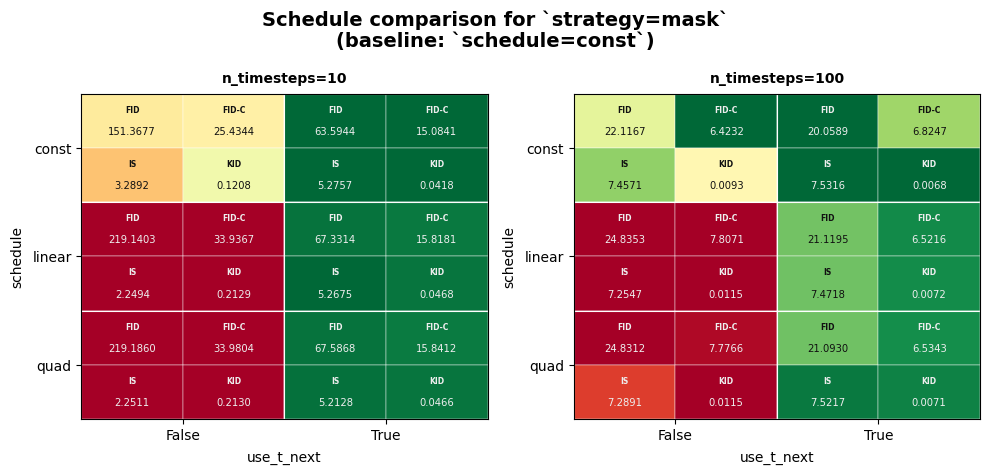

In [74]:
df_img = pd.read_csv(RESULTS_IMAGE_CSV)

fig1 = plot_heatmaps(
    df_img,
    value_col     = "fid",
    x_col         = "use_t_next",
    y_col         = "schedule",
    fixed_filters = {"renoise_factor": 1.0, "strategy": "mask"},
    subplot_cols  = ["n_timesteps"],
    ncols         = 2,
    suptitle      = "Schedule comparison for `strategy=mask`\n(baseline: `schedule=const`)",
    cell_size      = (5, 4),
    use_kid         = True,
)
plt.show()

## 9.2 - Impact of fixing noise addition

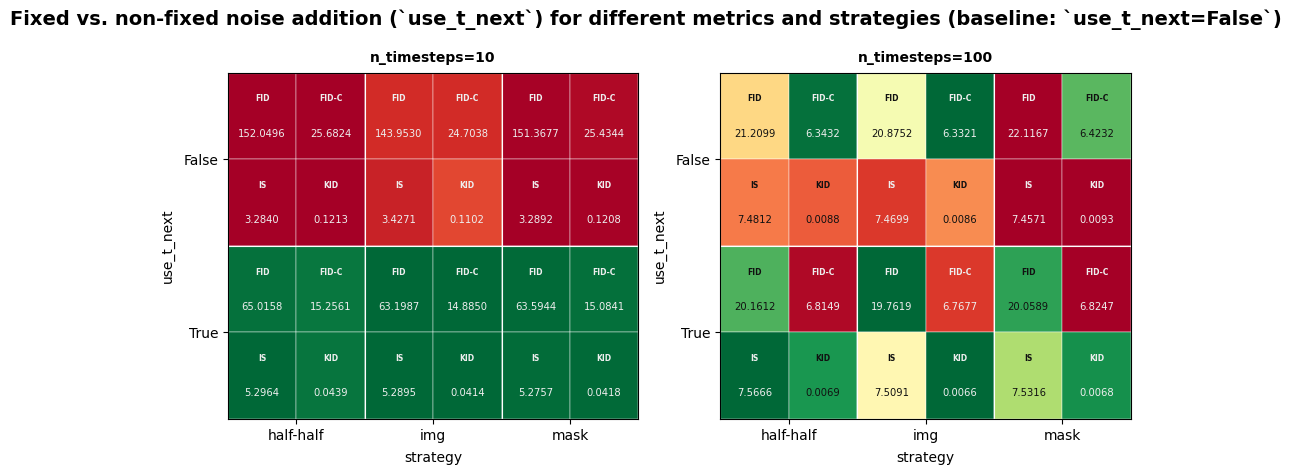

In [75]:
fig1 = plot_heatmaps(
    df_img,
    value_col     = "fid",
    x_col         = "strategy",
    y_col         = "use_t_next",
    fixed_filters = {"renoise_factor": 1.0, "schedule": "const"},
    subplot_cols  = ["n_timesteps"],
    ncols         = 2,
    suptitle      = "Fixed vs. non-fixed noise addition (`use_t_next`) for different metrics and strategies (baseline: `use_t_next=False`)",
    cell_size      = (5, 4),
    use_kid         = True,
)
plt.show()

## 9.3 - Impact of increasing noise in the sampling process

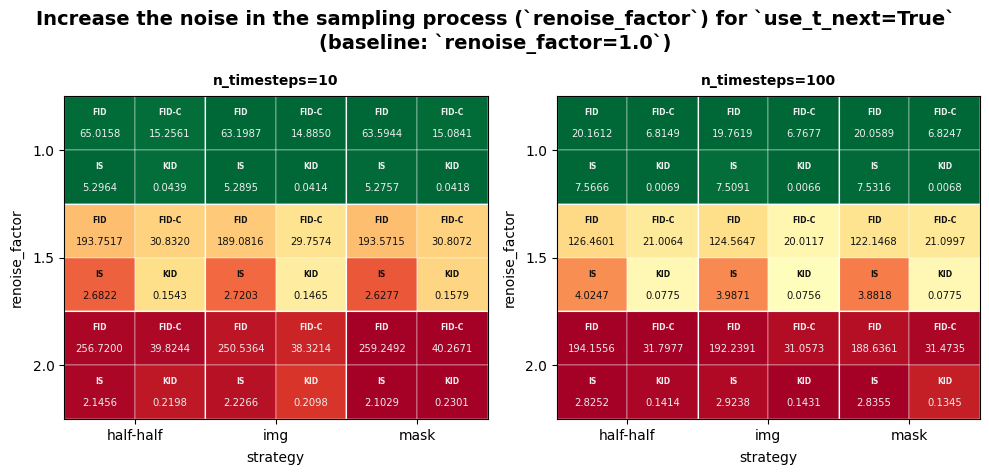

In [76]:
fig1 = plot_heatmaps(
    df_img,
    value_col     = "fid",
    x_col         = "strategy",
    y_col         = "renoise_factor",
    fixed_filters = {"use_t_next": True, "schedule": "const"},
    subplot_cols  = ["n_timesteps"],
    ncols         = 2,
    suptitle      = "Increase the noise in the sampling process (`renoise_factor`) for `use_t_next=True`\n(baseline: `renoise_factor=1.0`)",
    cell_size      = (5, 4),
    use_kid         = True,
)
plt.show()

Note: notebook mostly generated by Claude Sonnet 4.6 (Free)